In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

#далее идут вспомогательные функции и переменные, необходимые для работы программ. Для работы реализаций их нужно активировать.

w = np.array([0.299, 0.587, 0.114])

def timeitTest(Func, *args):
  fName = Func.__name__
  if (fName[-1] == '1'): timeitRes = %timeit -q -o -n 3 Func(*args)
  else: timeitRes = %timeit -q -o -n 20 Func(*args)
  return timeitRes

def primeFactorization(num):
  k, fArr = 2, []
  while k * k <= num:
    while num%k == 0:
      fArr.append(k)
      num //= k
    k+=1
  if num > 1: fArr.append(num)
  return fArr

def estimate_coef(x, y):
  n = np.size(x)
  m_x = np.mean(x)
  m_y = np.mean(y)
  SS_xy = np.sum(y*x) - n*m_y*m_x
  SS_xx = np.sum(x*x) - n*m_x*m_x
  b_1 = SS_xy / SS_xx
  b_0 = m_y - b_1*m_x
  return (b_0, b_1)

def plot3TimeTests(Func1, Func2, Func3, arrSizes, arrTime1, arrTime2, arrTime3):
  plt.plot(arrSizes, arrTime1, marker=".", label=Func1.__name__)
  plt.plot(arrSizes, arrTime2, marker=".", label=Func2.__name__)
  plt.plot(arrSizes, arrTime3, marker=".", label=Func3.__name__)
  plt.legend()
  plt.show()

def plot2TimeTests(Func2, Func3, arrSizes, arrTime2, arrTime3):
  plt.plot(arrSizes, arrTime2, marker=".", label=Func2.__name__)
  plt.plot(arrSizes, arrTime3, marker=".", label=Func3.__name__)
  plt.legend()
  plt.show()

def plot2TimeRegression(Func2, Func3, arrSizes, arrTime2, arrTime3):
  b2 = estimate_coef(arrSizes, arrTime2)
  b3 = estimate_coef(arrSizes, arrTime3)
  plt.plot(arrSizes, b2[0] + b2[1]*arrSizes, marker=".", label=Func2.__name__)
  plt.plot(arrSizes, b3[0] + b3[1]*arrSizes, marker=".", label=Func3.__name__)
  plt.legend()
  plt.show()

**Задача 1**

Найти произведение ненулевых элементов на диагонали матрицы.

Composition of non-zero elements in matrix:
 [[1 0 1]
 [2 0 2]
 [3 0 3]
 [4 4 4]] 
Func11: 3 
Func12: 3 
Func13: 3
Plotting results of measuring time depending on array size (100, 10000) with step 100 for 3 realizations


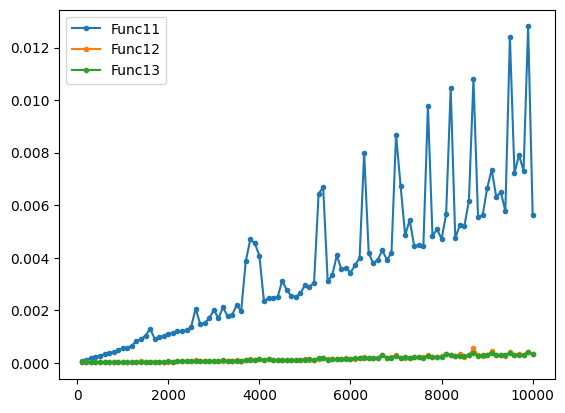

Plotting results of measuring time depending on array size (100, 10000) with step 100 for 2 faster realizations


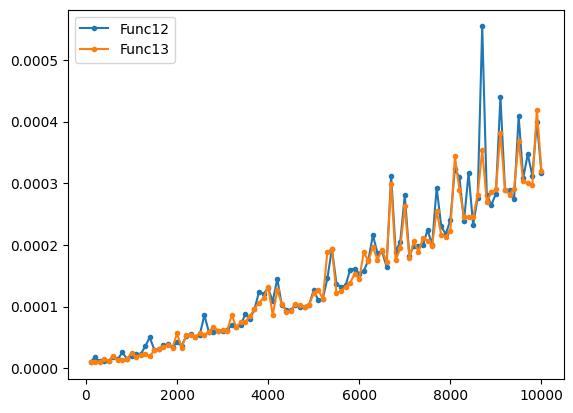

Plotting regression line of time depending on array size (100, 10000) with step 100 for 2 faster realizations


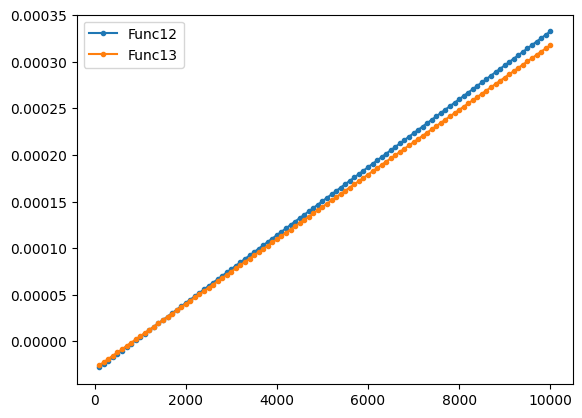

All tests OK: True


In [ ]:
def Func11(X): #1.1
  dim = X.shape
  nRow, nCol = dim[0], dim[1]
  if nCol <= nRow: dSize = nCol
  else: dSize = nRow
  mul = 1
  for i in range(dSize):
    if X[i][i] != 0:
      mul*=X[i][i]
  return mul

def Func12(X): #1.2
  dim = X.shape
  nRow, nCol = dim[0], dim[1]
  if nCol <= nRow: dSize = nCol
  else: dSize = nRow
  diagX = X.reshape(nRow*nCol)[0:(dSize - 1)*nCol + dSize:nCol + 1] #получаем диагональ матрицы
  return np.prod(diagX[diagX != 0])

def Func13(X): #1.3
  diagX = np.diagonal(X)
  return np.prod(diagX[diagX != 0])

#проверка результата на простом примере:
X = np.array([[1, 0, 1], [2, 0, 2], [3, 0, 3], [4, 4, 4]])
res11, res12, res13 = Func11(X), Func12(X), Func13(X)
print("Composition of non-zero elements in matrix:\n", X, "\nFunc11:" , res11, "\nFunc12:", res12, "\nFunc13:", res13)

#тестирование времени выполнения на случайных матрицах при фиксированных их размерах и проверка эквивалентности результатов:
arrSizes1 = np.arange(100, 10100, 100)
arrTime11, arrTime12, arrTime13 = np.empty(100), np.empty(100), np.empty(100)
isEqual1 = True
for i in range(100):
  X = 1.0*np.random.randint(-1, 2, arrSizes1[i]*arrSizes1[i])
  X[X == 1.0], X[X == -1.0] = 1.001, 0.999
  X = X.reshape(arrSizes1[i], arrSizes1[i])
  res11, res12, res13 = Func11(X), Func12(X), Func13(X)
  arrTime11[i], arrTime12[i], arrTime13[i] = timeitTest(Func11, X).average, timeitTest(Func12, X).average, timeitTest(Func13, X).average
  isEqual1 = isEqual1 and res11 == res12 and res12 == res13
print("Plotting results of measuring time depending on array size (100, 10000) with step 100 for 3 realizations")
plot3TimeTests(Func11, Func12, Func13, arrSizes1, arrTime11, arrTime12, arrTime13)
print("Plotting results of measuring time depending on array size (100, 10000) with step 100 for 2 faster realizations")
plot2TimeTests(Func12, Func13, arrSizes1, arrTime12, arrTime13)
print("Plotting regression line of time depending on array size (100, 10000) with step 100 for 2 faster realizations")
plot2TimeRegression(Func12, Func13, arrSizes1, arrTime12, arrTime13)
print("All tests OK:", isEqual1)


**Выводы по задаче 1.** Было получено произведение ненулевых элементов на диагонали матрицы тремя различными способами. С помощью графического представления и линейно-регрессионного анализа времени выполнения при различных тестах можно сделать следующие выводы по времени выполнения.

Первый способ (Func11), реализованный только через циклы, оказался самым медленным ввиду поэлементного обращения к массиву.

Второй способ (Func12), реализованный через приведение матрицы к одномерному массиву и механизм слайсинга, оказался гораздо быстрее использования циклов, ввиду того, что массивы numpy обладают под капотом механизмом векторизации (один из видов распараллеливания). По сути это означает, что за один такт процессора можно выполнить операции сразу над несколькими числами, образующих структуру вектора или матрицы.

Третий способ (Func13) более читаемый, так как использует встроенную функцию np.diagonal, которая сразу говорит, что она делает. Судя по графикам и полученной линейно-регрессионной зависимости можно сказать, что скорость её выполнения такая же, как и у второй реализации.

**Задача 2**

Проверить на эквивалентность два заданных мультимножества

Is equivalent multisets: [1 2 2 4] and [4 2 1 2] ?
Func21: True 
Func22: True 
Func23: True
Is equivalent multisets:  [1 2 2 4 5 4] and [4 2 1 2 5 5] ?
Func21: False 
Func22: False 
Func23: False
Plotting results of measuring time depending on array size (10, 1000) with step 10 and with max. element 100 for 3 realizations


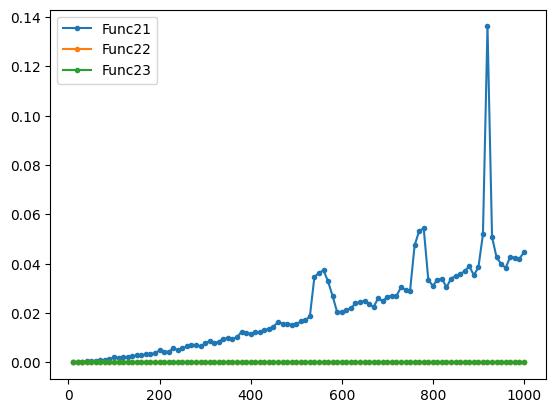

Plotting results of measuring time depending on array size (10, 1000) with step 10 and with max. element 100 for 2 faster realizations


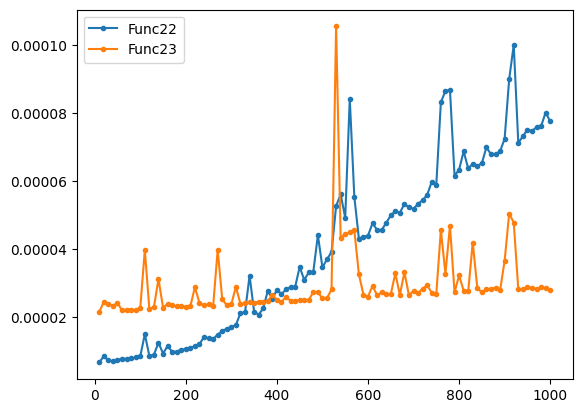

All tests OK: True
Plotting results of measuring time depending on array size (10, 1000) with step 10 and with max. element 40000 for 2 faster realizations


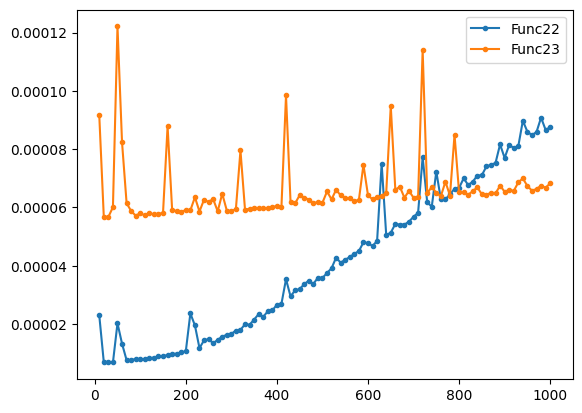

All tests OK: True


In [ ]:
def Func21(x, y):
  xSize, ySize = x.size, y.size
  if xSize != ySize: return False
  delCount = 0
  while delCount < xSize:
    isDeleted = False
    j = 0
    while j < ySize - delCount:
      if(x[xSize - delCount - 1] == y[j]):
        x, y = np.delete(x, xSize - delCount - 1, 0), np.delete(y, j, 0)
        delCount+=1
        isDeleted = True
        break
      j+=1
    if not(isDeleted): return False
  return True

def Func22(x, y):
  if x.size != y.size: return False
  return np.array_equal(np.sort(x), np.sort(y))

def Func23(x, y):
  xSize = x.size
  if xSize != y.size: return False
  xMin, yMin = np.min(x), np.min(y)
  if xMin == yMin and np.max(x) == np.max(y): return np.array_equal(np.bincount(x - xMin), np.bincount(y - yMin))
  return False

#проверка на эквивалетных мультимножествах
x, y = np.array([1, 2, 2, 4]), np.array([4, 2, 1, 2])
res21, res22, res23 = Func21(x, y), Func22(x, y), Func23(x, y)
print("Is equivalent multisets:", x, "and", y, "?\nFunc21:", res21, "\nFunc22:", res22, "\nFunc23:", res23)

#проверка на неэквивалетных мультимножествах
x, y = np.array([1, 2, 2, 4, 5, 4]), np.array([4, 2, 1, 2, 5, 5])
res21, res22, res23 = Func21(x, y), Func22(x, y), Func23(x, y)
print("Is equivalent multisets: ", x, "and", y, "?\nFunc21:", res21, "\nFunc22:", res22, "\nFunc23:", res23)

#тестирование времени выполнения на случайных эквивалентных мультимножествах при фиксированных их размерах и разбросе элементов, и проверка эквивалентности результатов:
maxElem = 100
arrTime21, arrTime22, arrTime23 = np.empty(100), np.empty(100), np.empty(100)
arrSizes2 = np.arange(10, 1010, 10)
isEqual2 = True
for i in range(100):
  x = np.r_[0, np.random.randint(1, maxElem, size=arrSizes2[i] - 2), maxElem]
  np.random.shuffle(x)
  y = np.copy(x)
  np.random.shuffle(y)
  res21, res22, res23 = Func21(x, y), Func22(x, y), Func23(x, y)
  arrTime21[i], arrTime22[i], arrTime23[i] = timeitTest(Func21, x, y).average, timeitTest(Func22, x, y).average, timeitTest(Func23, x, y).average
  isEqual2 = isEqual2 and res21 and res22 and res23
print("Plotting results of measuring time depending on array size (10, 1000) with step 10 and with max. element", maxElem, "for 3 realizations")
plot3TimeTests(Func21, Func22, Func23, arrSizes2, arrTime21, arrTime22, arrTime23)
print("Plotting results of measuring time depending on array size (10, 1000) with step 10 and with max. element", maxElem, "for 2 faster realizations")
plot2TimeTests(Func22, Func23, arrSizes2, arrTime22, arrTime23)
print("All tests OK:", isEqual2)
#увеличение разброса значений элементов повлияет в худшую сторону на производительность третьего алгоритма:
maxElem = 40000
isEqual2 = True
for i in range(100):
  x = np.r_[0, np.random.randint(1, maxElem, size=arrSizes2[i] - 2), maxElem]
  np.random.shuffle(x)
  y = np.copy(x)
  np.random.shuffle(y)
  res22, res23 = Func22(x, y), Func23(x, y)
  arrTime22[i], arrTime23[i] = timeitTest(Func22, x, y).average, timeitTest(Func23, x, y).average
  isEqual2 = isEqual2 and res22 and res23
print("Plotting results of measuring time depending on array size (10, 1000) with step 10 and with max. element", maxElem, "for 2 faster realizations")
plot2TimeTests(Func22, Func23, arrSizes2, arrTime22, arrTime23)
print("All tests OK:", isEqual2)

**Выводы по задаче 2.** Были получены реализации, позволяющие сравнивать мультимножества. Так бы были получены графические результаты тестов (100 тестов на диапазоне размера 10 - 1000 элементов с шагом 10) по измерению времени выполнения в зависимости от размера массива.

Первая реализация  (Func21), реализованный только через циклы, оказался самым медленным ввиду квадратичной сложности алгоритма и поэлементного обращения к массивам. Но плюсом данной реализации служит то, что данные в массиве могут быть произвольного типа.

Вторая реализация (Func22), реализованный через встроенную в numpy функцию сортировки, отказался гораздо быстрее, но данные могут быть только такими, для которых существует отношение порядка.  

Третий способ (Func23), использующий реализацию гистограммы и
подсчитывающий количество элементов каждого типа в массиве, оказывается самым быстрым особенно при большом размере массива, но с одной оговоркой. Если разброс значений в исходных массивах сравним с размером массива, то третья реализация эффективна. Если же размер массивов много меньше максимального разброса значений в них, то данный алгоритм становится менее эффективным + увеличивается расход по памяти.

**Задача 3**

Найти максимальный элемент после 0 в заданном массиве.

Maximum element after zero in: [6 2 0 3 0 0 5 7 0] :
Func31: 5 
Func32: 5 
Func33: 5
Plotting results of measuring time depending on array size (100, 10000) with step 100 for 3 realizations


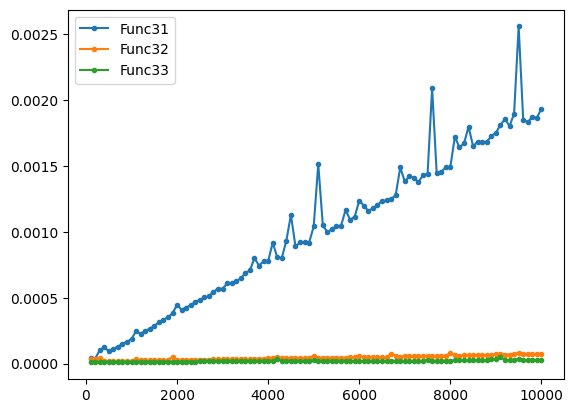

Plotting results of measuring time depending on array size (100, 10000) with step 100 for 2 faster realizations


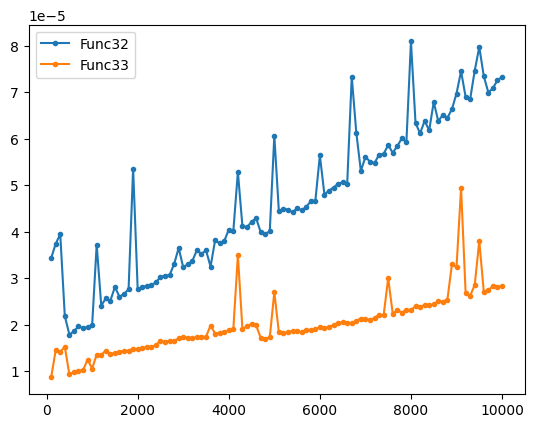

Plotting line regression of time depending on array size (100, 10000) with step 100 for 2 faster realizations


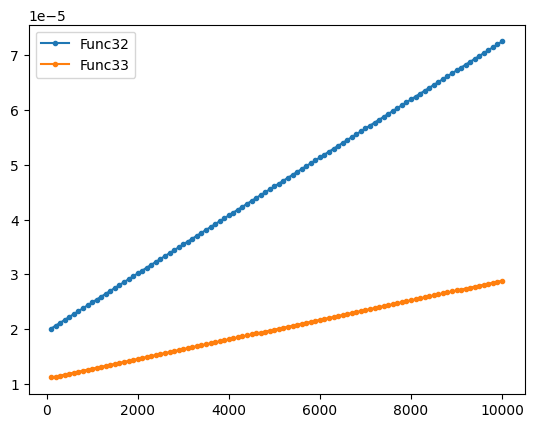

All tests OK: True


In [ ]:
def Func31(x): #3.1
  max, xSize = 0, x.size
  for i in range(xSize - 1):
    if x[i] == 0 and x[i+1] > max:
      max = x[i+1]
  return max

def Func32(x): #3.2
  return np.max(x[np.r_[False, x[1:] - x[:-1] == x[1:]]]) #через разницу

def Func33(x): #3.3
  return np.max(x[np.where(x[:-1] == 0)[0] + 1]) #через np.where

#проверка результата на простом примере:
x = np.array([6, 2, 0, 3, 0, 0, 5, 7, 0])
res31, res32, res33 = Func31(x), Func32(x), Func33(x)
print("Maximum element after zero in:", x, ":\nFunc31:", res31, "\nFunc32:", res32, "\nFunc33:", res33)

#тестирование времени выполнения на случайных массивах при фиксированных их размерах и кол-вах нулей, и проверка эквивалентности результатов:
arrSizes3 = np.arange(100, 10100, 100)
arrTime31, arrTime32, arrTime33 = np.empty(100), np.empty(100), np.empty(100)
isEqual3 = True
for i in range(100):
  nZero = 20 + i*20
  x = np.r_[np.zeros(nZero, dtype=int), np.random.randint(1, 100000, arrSizes3[i] - nZero)]
  np.random.shuffle(x)
  res31, res32, res33 = Func31(x), Func32(x), Func33(x)
  arrTime31[i], arrTime32[i], arrTime33[i] = timeitTest(Func31, x).average, timeitTest(Func32, x).average, timeitTest(Func33, x).average
  isEqual3 = isEqual3 and res31 == res32 and res32 == res33
print("Plotting results of measuring time depending on array size (100, 10000) with step 100 for 3 realizations")
plot3TimeTests(Func31, Func32, Func33, arrSizes3, arrTime31, arrTime32, arrTime33)
print("Plotting results of measuring time depending on array size (100, 10000) with step 100 for 2 faster realizations")
plot2TimeTests(Func32, Func33, arrSizes3, arrTime32, arrTime33)
print("Plotting line regression of time depending on array size (100, 10000) with step 100 for 2 faster realizations")
plot2TimeRegression(Func32, Func33, arrSizes3, arrTime32, arrTime33)
print("All tests OK:", isEqual3)

**Выводы по задаче 3.** Были получены реализации, позволяющие находить максимальный элемент в массиве, стоящий после нуля. Так бы были получены графические результаты тестов (всего 100 тестов) по измерению времени выполнения в зависимости от размера массива. Для убирания шума и большей наглядности была построена линейная регрессия для более быстрых реализаций (это уместно, так как их сложность O(n)).

Первая реализация  (Func31), реализованная только через циклы, работает медленнее всех.

Вторая реализация (Func32), реализованная через сдвиг массива на один элемент вправо и разницу сдвинутого массива с исходным, оказалась гораздо быстрее цикла.

Третий способ (Func33) реализован аналогично второй реализации, но использует сравнение массива без последнего элемента с 0, вместо разности сдвинутого массива с ним. Он оказывается немного быстрее второй реализации, если судить по графикам тестов и по их линейно-регрессионному анализу, убирающему хаотичные выбросы. И это очевидно, ведь операция сравнения как правило быстрее операции сложения. Да и читается третья реализация проще, так как в том числе используется встроенная функция np.where, которая говорит сама за себя.

**Задача 4**

Преобразовать цветное RGB-изображение в чёрно-белое.

Func41 result = Func42 result and Func42 result = Func43 result! New image is saved as newPngImage.png
Plotting results of measuring time depending on pixel count (100, 10000) with step 100 for 3 realizations


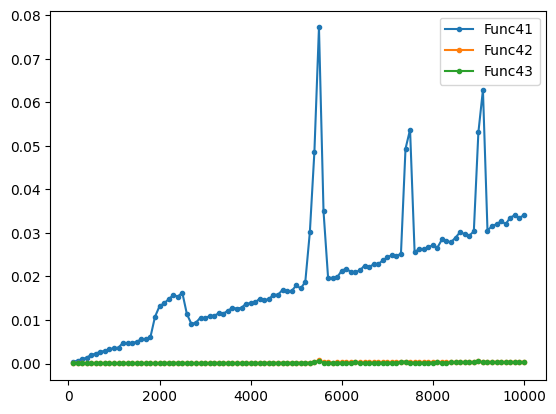

Plotting results of measuring time depending on pixel count (100, 10000) with step 100 for 2 faster realizations


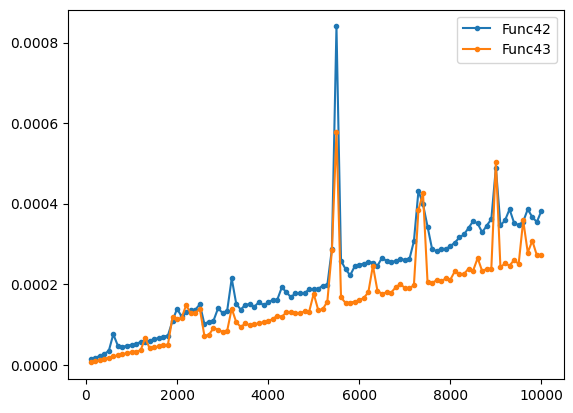

Plotting regression line of time depending on pixel count (100, 10000) with step 100 for 2 faster realizations


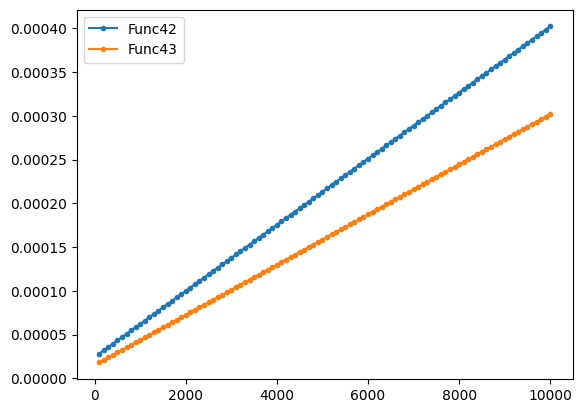

All tests OK: True


In [3]:
def Func41(pixMatr): #4.1
  dim = pixMatr.shape
  newPixMatr = np.empty((dim[0], dim[1]), dtype=np.uint8)
  for i in range(dim[0]):
    for j in range(dim[1]):
      sum = 0
      for k in range(dim[2]):
        sum+=w[k]*pixMatr[i][j][k]
      newPixMatr[i][j] = np.uint8(sum)
  return newPixMatr

def Func42(pixMatr): #4.2
  return np.sum(pixMatr*w, axis = 2).astype(np.uint8)

def Func43(pixMatr): #4.3
  return np.dot(pixMatr, w).astype(np.uint8)
#проверка результата на реальном изображении:
im = imageio.imread('https://imgbly.com/ib/HRG4djDY2K.png')
res41, res42, res43 = Func41(im), Func42(im), Func43(im)
if np.array_equal(res41, res42) and np.array_equal(res42, res43):
  imageio.imsave('/content/newPngImage.png', res41)
  print("Func41 result = Func42 result and Func42 result = Func43 result! New image is saved as newPngImage.png")
else: print("Results are non - equivalent! New image is not saved.")

#тестирование времени выполнения на случайных матрицах при фиксированных количествах пикселей, и проверка эквивалентности результатов:
arrSizes4 = np.arange(100, 10100, 100)
arrTime41, arrTime42, arrTime43 = np.empty(100), np.empty(100), np.empty(100)
isEqual4 = True
for i in range(100):
  factorArr = np.array(primeFactorization(arrSizes4[i]))#получаем разложение на простые множители числа элементов в матрице
  np.random.shuffle(factorArr)
  nRow, nCol = np.prod(factorArr[:factorArr.size//2]), np.prod(factorArr[factorArr.size//2:])#получаем количество строк и столбцов по разложению
  im = np.random.randint(0, 256, (nRow, nCol, 3)).astype(np.uint8)
  res41, res42, res43 = Func41(im), Func42(im), Func43(im)
  arrTime41[i], arrTime42[i], arrTime43[i] = timeitTest(Func41, im).average, timeitTest(Func42, im).average, timeitTest(Func43, im).average
  isEqual4 = isEqual4 and np.array_equal(res41, res42) and np.array_equal(res42, res43)
print("Plotting results of measuring time depending on pixel count (100, 10000) with step 100 for 3 realizations")
plot3TimeTests(Func41, Func42, Func43, arrSizes4, arrTime41, arrTime42, arrTime43)
print("Plotting results of measuring time depending on pixel count (100, 10000) with step 100 for 2 faster realizations")
plot2TimeTests(Func42, Func43, arrSizes4, arrTime42, arrTime43)
print("Plotting regression line of time depending on pixel count (100, 10000) with step 100 for 2 faster realizations")
plot2TimeRegression(Func42, Func43, arrSizes4, arrTime42, arrTime43)
print("All tests OK:", isEqual4)

**Выводы по задаче 4.** Были получены реализации, позволяющие преобразовывать цветное RGB-изображение в чёрно-белое. Так же было проведено 100 тестов на входных данных разных размеров (значения данные задаются случайно). Во время каждого этих тестов было замерено среднее время выполнения и занесено в график. Для убирания шума и большей наглядности была построена линейная регрессия для более быстрых реализаций (это уместно, так как их сложность O(n)).

Первая реализация  (Func41), реализованная только через циклы, работает медленнее всех по понятной причине.

Вторая реализация (Func42), реализованная через поэлементное умножение матрицы на вектор и последующее суммирование элементов по третьему измерению, работает быстрее цикла, но не так быстро, ввиду того, что есть последовательное получение данных (сначала произведение, а потом сумма). Данную последовательность вычислений так же можно было бы совместно ускорить, на мой взгляд.

Третий способ (Func43), реализованный аналогично второй реализации, но использующий встроенную функцию свёртки или матричного перемножения, как раз работает немного быстрее второй реализации. Видимо внутри данной реализации как раз и используется дополнительная векторизация, которой нет в Func42.

**Задача 5**

Сделать Run-length encoding кодирование заданного массива.

Run-length encoding of [2 2 2 3 3 3 5 2 2] :
Func51: (array([2, 3, 5, 2]), array([3, 3, 1, 2])) 
Func52: (array([2, 3, 5, 2]), array([3, 3, 1, 2])) 
Func53: (array([2, 3, 5, 2]), array([3, 3, 1, 2]))
Plotting results of measuring time depending on array size (100, 10000) with step 100 for 3 realizations


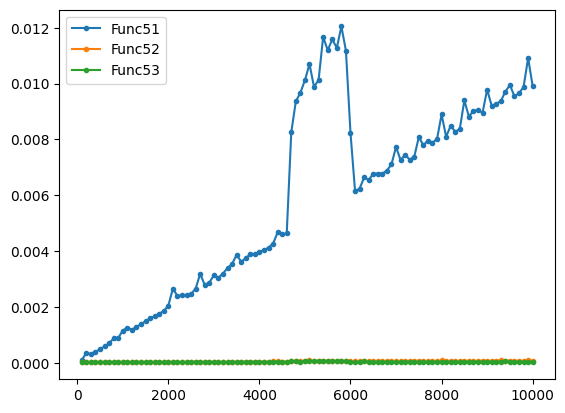

Plotting results of measuring time depending on array size (100, 10000) with step 100 for 2 faster realizations


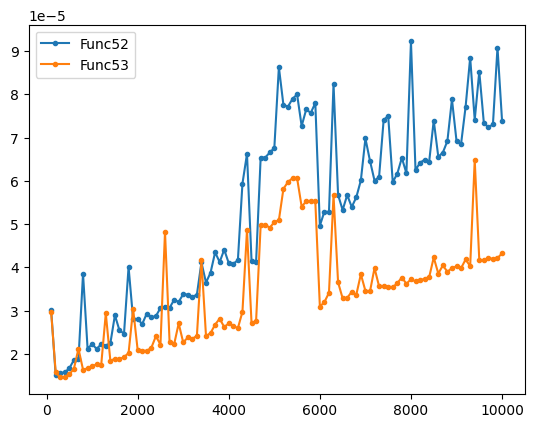

Plotting regression line of time depending on array size (100, 10000) with step 100 for 2 faster realizations


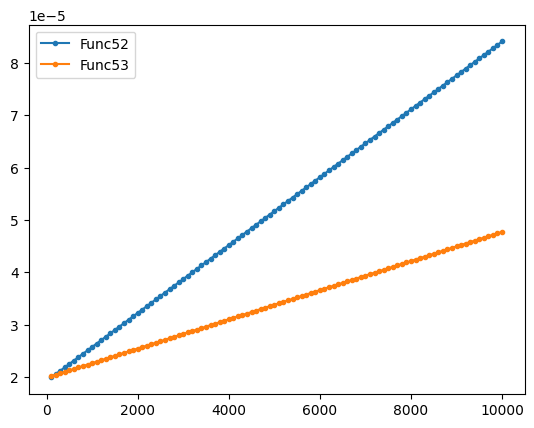

All tests OK: True


In [ ]:
def Func51(x): #5.1
  k, i, xSize = 0, 0, x.size
  while i < xSize:
    while i < xSize - 1 and x[i+1] == x[i]:
      i+=1
    k+=1
    i+=1
  nums = np.empty(k, dtype = int)
  repeats = np.empty(k, dtype = int)
  k, i = 0, 0
  while i < xSize:
    rep = 1
    nums[k] = x[i]
    while i < xSize - 1 and x[i+1] == x[i]:
      rep+=1
      i+=1
    repeats[k] = rep
    k+=1
    i+=1
  return (nums, repeats)

def Func52(x): #5.2
  diffArr = np.r_[1, x[1:] - x[:-1], 1] #вычисление индикаторного массива через сдвиг на один элемент и разницу
  indIn = np.where(diffArr)[0]
  return (x[indIn[:-1]], indIn[1:] - indIn[:-1])

def Func53(x): #5.3
  idArr = np.r_[True, x[1:] != x[:-1], True] #вычисление индикаторного массива через сдвиг на один элемент и сравнение (это немного ускорит работу)
  indIn = np.where(idArr)[0]
  return (x[indIn[:-1]], indIn[1:] - indIn[:-1])

#проверка результата на простом примере:
x = np.array([2, 2, 2, 3, 3, 3, 5, 2, 2])
res51, res52, res53 = Func51(x), Func52(x), Func53(x)
print("Run-length encoding of", x, ":\nFunc51:", res51, "\nFunc52:", res52, "\nFunc53:", res53)

#тестирование времени выполнения на случайных массивах при фиксированных размерах, и проверка эквивалентности результатов:
arrSizes5 = np.arange(100, 10100, 100)
arrTime51, arrTime52, arrTime53 = np.empty(100), np.empty(100), np.empty(100)
isEqual5 = True
for i in range(100):
  x = np.random.randint(1, 10, arrSizes5[i])
  res51, res52, res53 = Func51(x), Func52(x), Func53(x)
  arrTime51[i], arrTime52[i], arrTime53[i] = timeitTest(Func51, x).average, timeitTest(Func52, x).average, timeitTest(Func53, x).average
  isEqual5 = isEqual5 and np.array_equal(res51[0], res52[0]) and np.array_equal(res52[0], res53[0]) and np.array_equal(res51[1], res52[1]) and np.array_equal(res52[1], res53[1])
print("Plotting results of measuring time depending on array size (100, 10000) with step 100 for 3 realizations")
plot3TimeTests(Func51, Func52, Func53, arrSizes5, arrTime51, arrTime52, arrTime53)
print("Plotting results of measuring time depending on array size (100, 10000) with step 100 for 2 faster realizations")
plot2TimeTests(Func52, Func53, arrSizes5, arrTime52, arrTime53)
print("Plotting regression line of time depending on array size (100, 10000) with step 100 for 2 faster realizations")
plot2TimeRegression(Func52, Func53, arrSizes5, arrTime52, arrTime53)
print("All tests OK:", isEqual5)

**Выводы по задаче 5.** Были получены реализации, позволяющие преобразовывать массив в кортеж из двух массивов по принципу run-length enconing. Так же было проведено 100 тестов на входных данных разных размеров при фиксированном и небольшом разбросе данных (чтобы группы повторов стабильно формировались). Во время каждого этих тестов было замерено среднее время выполнения и занесено в график. Для убирания шума и большей наглядности была построена линейная регрессия для более быстрых реализаций (это уместно, так как их сложность O(n)).

Первая реализация  (Func51), реализованная только через циклы, работает медленнее всех по той же причине, что и в других задачах (поэлементное обращение к элементам массива).

Вторая реализация (Func52) реализована подобно второй реализации в третьей задаче. Убирается первый элемент в начале массива (сдвиг). И из этого сдвинутого массива вычитается исходный массив без последнего элемента. Так же добавим в начало и конец не нулевой элемент. Таким образом, все группы повторяющихся элементов будут начинаться с не нулевого элемента, и продолжаться нулями, пока группа не закончится. Далее всё понятно, получаем индексы ненулевых элементов, и попарно вычитаем. В итоге получаем размеры повторяющихся групп.

Третий способ (Func53) реализован аналогично второй реализации, но использует вместо разности сравнение. Это удобно при чтении кода, и работает немного быстрее, потому что сравнение делается немного быстрее, чем вычитание, что подтверждает регрессионный анализ полученных графиков измерения времени.